In [1]:
import catalogue_analysis as ca
import redshift_weights as rw
import numpy as np
from astropy.table import join,Table,Column,vstack,setdiff
from astropy.io import fits

######################################################################################################################
# Select list of catalogues on which analysis is based
FileSet = 'Y3'
info = True              #choose whether to echo stats on each dataset
fresh_kcorr = False       #choose whether to recompute k-corrections and restframe colours or use existing tables
plot = False             #set to false if you don't want so many diagnostic plots
PhotometryMatch =  False #Empircally debias N colours and S magnitudes
######################################################################################################################

if (FileSet == 'Y1'):
  #Load the catalogue  (set fpath as required)
  fpathN='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_N_clustering.dat.fits' #clustering catalogue north
  fpathS='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_S_clustering.dat.fits' #clustering catalogue south
  #load clustering catalogue  (Y1 was in two parts which we concaternate)
  datall=ca.load_catalogues(fpathN,fpathS)
  fullfile='/pscratch/sd/a/amjsmith/Y1/LSS/iron/LSScats/v0.5/BGS_BRIGHT_full.dat.fits'  # full observed catalogue used for redshift weights 
  fsffile='./data/fastspec-iron-main-bright.fits' #fsf file used for k-corrections  
elif (FileSet == 'Y3'):
  fpath='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/nonKP/BGS_BRIGHT_clustering.dat.fits' #clustering catalogue
  datall=ca.Y3load_catalogues(fpath)
  #Load clustering catalogue  
  fullfile='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/BGS_BRIGHT_full_HPmapcut.dat.fits' #full observed catalogue used for redshift weights 
  fsffile='./data/fastspec-iron-main-bright.fits' #fsf file used for k-corrections  
else:
  print('Set of files on which analysis is to be based is not specified')

# Read full observed catalogue and extract the observed (meeting certain cuts) and zgood (also has good redshift) subsets 
zgood,observed= ca.load_full_catalogue_subsets(fullfile)
if (info):
    print('Statistics of the observed catalogue:')
    observed.info('stats')
    print('Statistics of the zgood catalogue:')
    zgood.info('stats')

if (info):
    print('Statistics of the clustering catalogue:')
    datall.info('stats')    

#Specify regions to loop over
regions=('N', 'S')


#Random sample and apply all cuts from the start for a quick run through
Sel=ca.selection('N')# import North selection cuts  
smaskN= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) & (np.random.rand(datall['Z'].size)<Sel['f_ran'])\
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='N') 
Sel=ca.selection('S') # import South selection cuts    
smaskS= (datall['Z'] > Sel['zmin']) & (datall['Z'] < Sel['zmax']) &(np.random.rand(datall['Z'].size)<Sel['f_ran']) \
& (datall['rmag'] < Sel['faint'])  & (datall['rmag'] > Sel['bright']) & (datall['reg']=='S')
smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
dat=datall[smask]    
print('South sample size:',smaskS.sum())
print('North sample size:',smaskN.sum())




if (info):
    print('Statistics of the data catalogue after applying the selection cuts:')
    dat.info('stats')

Size of Full catalogue 10623399
Faintest Fibre mag: 25.411306 NB BGS was limited to r_fib=23 in an earlier version of the photometry
number of objects in the observed subset 7980009
number of objects in the good redshift subset 7887861
Faintest Observed Fibre mag: 25.411306
Statistics of the observed catalogue:
<Table length=7980009>
           name                mean         std         min          max      n_bad 
-------------------------- ------------ ----------- ------------ ----------- -------
                  TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16       0
                MWS_TARGET     0.164555     33.0836            0       10240       0
               SUBPRIORITY     0.545707    0.285051  6.22789e-07           1       0
             PRIORITY_INIT         2100           0         2100        2100       0
              TARGET_STATE           --          --           --          --       0
                 TIMESTAMP           --          --           --     

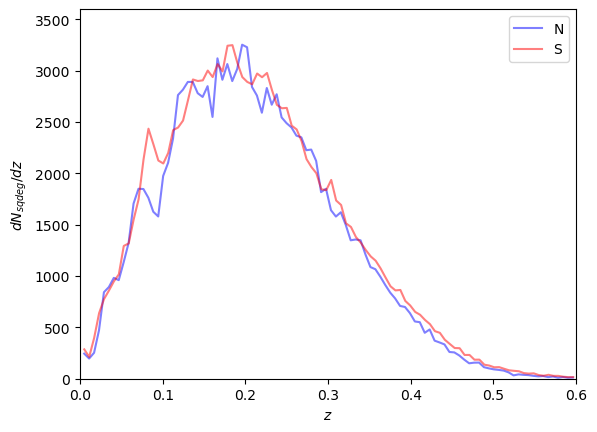

In [2]:
import matplotlib.pyplot as plt
for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dndz,binz=np.histogram(dat['Z'][regmask], bins=100,  weights=weights[regmask])
        bin_cen=(binz[1:]+binz[:-1])/2.0
        dz=binz[1]-binz[0] #redshift bin width
        dndz= (dndz/dz)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,dndz,color=Sel['col'],alpha=0.5,label=reg)    
plt.ylabel('$dN_{sq deg}/dz$')        
plt.xlabel('$z$')        
plt.xlim(0.0,0.6) 
plt.ylim(0.0,3600.0)
plt.legend()
plt.show()   

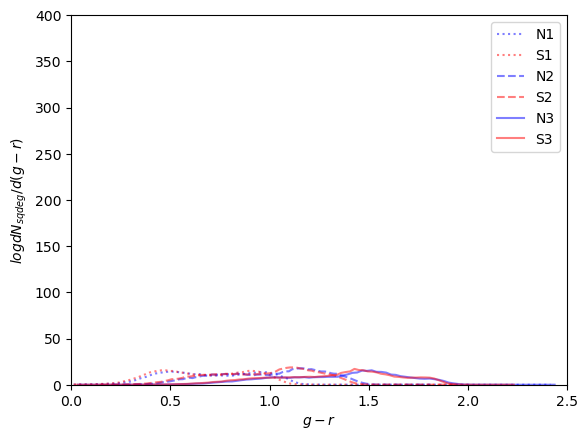

In [3]:
for slice in (1,2,3):
    if (slice==1): 
        zmin=0
        zmax=0.15
        ltype='dotted'
    if (slice==2): 
        zmin=0.15
        zmax=0.25
        ltype='dashed'
    if (slice==3): 
        zmin=0.25
        zmax=0.5
        ltype='solid'
    for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg) & ((dat['gmag']-dat['rmag'])>0.0) & ((dat['gmag']-dat['rmag'])<2.5)  & (dat['Z']>zmin) & (dat['Z']<zmax)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dn,bin=np.histogram((dat['gmag'][regmask]-dat['rmag'][regmask]), bins=100)
        bin_cen=(bin[1:]+bin[:-1])/2.0
        dcol=bin[1]-bin[0] #bin width
        dndcol= (dn/dcol)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,(dndcol),color=Sel['col'],alpha=0.5,label=reg+str(slice),linestyle=ltype)
plt.ylabel('$log dN_{sq deg}/d(g-r)$')        
plt.xlabel('$g-r$')        
plt.xlim(0.0,2.5) 
plt.ylim(0,400)
plt.legend()
plt.show()

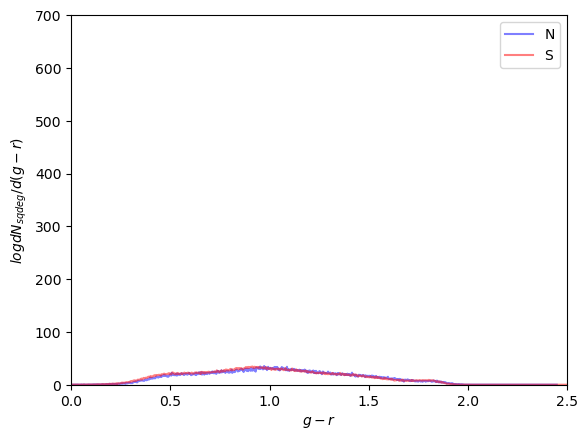

In [4]:
for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dn,bin=np.histogram((dat['gmag'][regmask]-dat['rmag'][regmask]), bins=1000)
        bin_cen=(bin[1:]+bin[:-1])/2.0
        dcol=bin[1]-bin[0] #bin width
        dndcol= (dn/dcol)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,(dndcol),color=Sel['col'],alpha=0.5,label=reg)
plt.ylabel('$log dN_{sq deg}/d(g-r)$')        
plt.xlabel('$g-r$')        
plt.xlim(0.0,2.5) 
plt.ylim(0,700)
plt.legend()
plt.show()   

/tmp/ipykernel_2288321/2685716143.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.plot(bin_cen,np.log10(dndm),color=Sel['col'],alpha=0.5,label=reg)


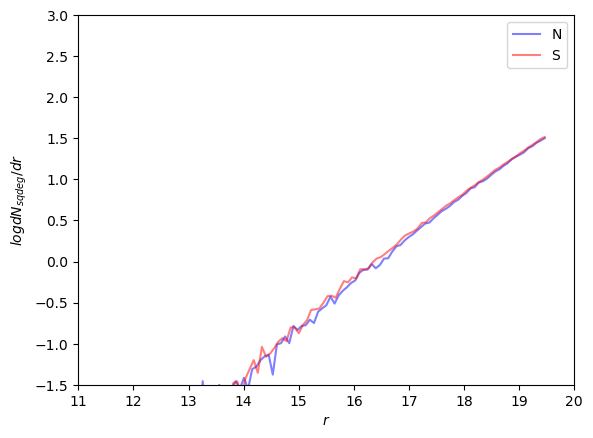

In [5]:
for reg in regions:
        Sel=ca.selection(reg) # define selection parameters for this region
        regmask = (dat['reg']==reg)
        weights=dat['WEIGHT']/Sel['f_ran']
        # A weighted histogram using the combined systematics and completeness weight  
        dn,bin=np.histogram(dat['rmag'][regmask], bins=100)
        bin_cen=(bin[1:]+bin[:-1])/2.0
        dm=bin[1]-bin[0] #bin width
        dndm= (dn/dm)/(Sel['area']*(4*np.pi*(180.0/np.pi)**2))   # rescale by area in sq deg and bin width 
        plt.plot(bin_cen,np.log10(dndm),color=Sel['col'],alpha=0.5,label=reg)
plt.ylabel('$log dN_{sq deg}/dr$')        
plt.xlabel('$r$')        
plt.xlim(11,20) 
plt.ylim(-1.5,3.0)
plt.legend()
plt.show()    

In [6]:
# If you want to recompute the colour lookup table and k-correction polynomials set fresh=True otherwise re-use stored table and fits
fresh = fresh_kcorr

if (fresh == True) :
  print('Recomputing colour look-up and k-correction polynomials')
  # Read John Moustakas's Fast Spec Catalogue
  fsf=ca.read_fsf(fsffile)
  print('statistics of the Fast Spectral Fitting Catalogue used for k-correction')
  fsf.info('stats')
  if PhotometryMatch :   #Force North to agree with South rest frame colour distribution
      print('Forcing South to agree with North rest frame colour distribution')
      fsf=ca.remapfsf_rmags(fsf,plot=plot)
      print('Statistics of modified FSF catalogue after forcing rest frame colour distributions to agree:')
      fsf.info('stats')
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=fresh,plot=plot)  
else:
  fsf='null' #just defining the variable so code doesn't complain  
  print('Using pre-computed colour look-up and k-correction polynomials')
  #compute rest frame colours and absolute magnitudes using k-corrections already computed from the fsf catalogue
  ca.recompute_rest_col_mag(dat,regions,fsf,fresh=False,plot=plot)

if (info):
   print('Statistics of the data catalogue after computing and adding rest frame colours and absolute magnitudes:')
   dat.info('stats')

Using pre-computed colour look-up and k-correction polynomials
Computing restframe colours for region  N using lookup for region  S
using precomputed k-corrections
LOADING IN LOOKUP TABLE
REST-FRAME COLOURS ASSIGNED.
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Computing restframe colours for region  S using lookup for region  S
using precomputed k-corrections
LOADING IN LOOKUP TABLE
REST-FRAME COLOURS ASSIGNED.
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Statistics of the data catalogue after computing and adding rest frame colours and absolute magnitudes:
<Table length=387228>
      name           mean        std         min          max    
---------------- ----------- ----------- ------------ -----------
        TARGETID 3.96296e+16 2.46793e+12  3.96273e+16 3.96373e+16
               Z    0.212607    0.104073   0.00200098    0.599557
           NTILE     2.43092    0.916785            1           5
              RA     

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat


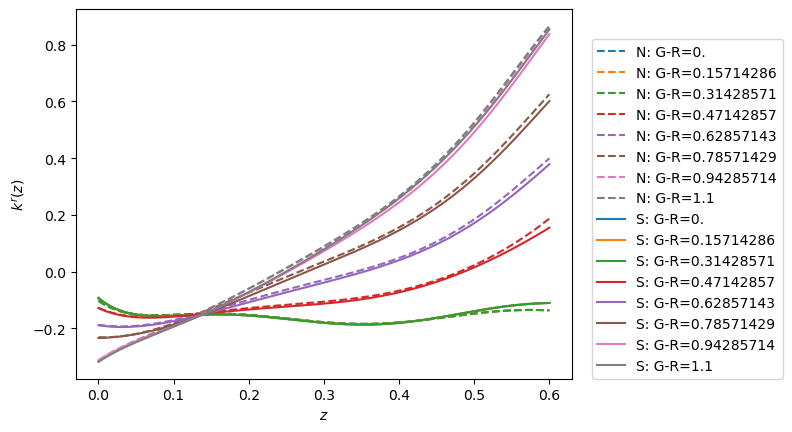

In [7]:
#Plot k-corrections to check they are well behaved
ca.plot_kcorr(regions)

In [ ]:
#
if PhotometryMatch : #Force absolute magnitude distribution of South to agree with North
   print('Forcing absolute magnitude distribution of South to agree with North')
   dat=ca.remap_rmags(dat,plot=plot)
   # As magnitudes have changed we have to reimpose the selection (we can do this and keep a complete sample if all the shifts make objects fainter)
   Sel=ca.selection('N')# import North selection cuts  
   smaskN= (dat['Z'] > Sel['zmin']) & (dat['Z'] < Sel['zmax']) \
   & (dat['rmag'] < Sel['faint'])  & (dat['rmag'] > Sel['bright']) & (dat['reg']=='N') 
   Sel=ca.selection('S') # import South selection cuts    
   smaskS= (dat['Z'] > Sel['zmin']) & (dat['Z'] < Sel['zmax']) \
   & (dat['rmag'] < Sel['faint'])  & (dat['rmag'] > Sel['bright']) & (dat['reg']=='S')
   smask= np.logical_or(smaskN,smaskS) #True for objects making cuts in North or South
   dat=dat[smask]    
   print('South sample size:',smaskS.sum())
   print('North sample size:',smaskN.sum())

In [ ]:
#colour-magnitude distributions
ca.plot_col_mag(dat,regions)
#sky plot
ca.sky_plot(dat,regions)

In [ ]:
# Construct the redshift weight table and add the fibmag and TSNR2_BGS columns to the data catalogue
dat=rw.construct_weight_table(dat, observed, zgood, plot=plot)
#Assign redshift incompleteness weights using now pre-computed look-up table
dat.info('stats')
rw.assign_redshift_weight(dat,regions)

starmask= (zgood['Z_not4clus']<0.00125)
print('nstars=',zgood['FLUX_R'][starmask].size,' nstars/ngood=',zgood['FLUX_R'][starmask].size/zgood['FLUX_R'].size)

dat.info('stats')

In [ ]:
#Match the dat and observed tables and copy data to add addtional columns to the dat table
len_before=len(dat)
dat = join(dat, observed['TARGETID','MORPHTYPE','EBV','PSFDEPTH_R','GALDEPTH_R','SHAPE_R'], keys='TARGETID')
len_after=len(dat)
if (len_before!=len_after): print('WARNING: dat table changed length when matching from ',length_before,' to ',length_after)


In [ ]:
# Compute zmax and vmax values
ca.compute_zmax_vmax(dat,regions)
#  
# Make some test plots but avoid plotting data from any unprocessed region
if (len(regions) > 1):
   regmask=  ((dat['reg']=='N') | (dat['reg']=='S'))
else:    
   regmask= (dat['reg']==regions)

if plot:    
    #Plots of how zmax depends on absolute magnitude, colour and redshift
    ca.plot_zmax_absmag(dat[regmask])
    ca.plot_zmax_z(dat[regmask])
    #Plots of how zmin depends on absolute magnitude, colour and redshift
    ca.plot_zmin_absmag(dat)
    ca.plot_zmin_z(dat[regmask])

In [ ]:
# Write the Augmented table to a fits file 
# Add meta data to store the selection cuts used in defining this sample and other information
Sel=ca.selection('N')
dat.meta['Qevol_N']=Sel['Qevol']
dat.meta['zmax_N']=Sel['zmax']
dat.meta['zmin_N']=Sel['zmin']
dat.meta['bright_N']=Sel['bright']
dat.meta['faint_N']=Sel['faint']
dat.meta['area_N']=Sel['area']
dat.meta['f_ran_N']=Sel['f_ran']
dat.meta['col_N']=Sel['col']
dat.meta['style_N']=Sel['style']

Sel=ca.selection('S')
dat.meta['Qevol_S']=Sel['Qevol']
dat.meta['zmax_S']=Sel['zmax']
dat.meta['zmin_S']=Sel['zmin']
dat.meta['bright_S']=Sel['bright']
dat.meta['faint_S']=Sel['faint']
dat.meta['area_S']=Sel['area']
dat.meta['f_ran_S']=Sel['f_ran']
dat.meta['col_S']=Sel['col']
dat.meta['style_S']=Sel['style']
#
# Store the parameters of the cosmology used to make this catalogue
dat.meta['H0']=ca.cosmo.H0.value
dat.meta['Tcmb0']=ca.cosmo.Tcmb0.value
dat.meta['Om0']=ca.cosmo.Om0
#
# Store the choices made for some of the processing option flags
dat.meta['PMatch']=PhotometryMatch

# Write the table complete with its meta data
#
dat.write('sdata/BGS_Y1_Oct2025.fits',overwrite=True) 


In [ ]:
# quick look at the stats of the final augmented data set
dat.info('stats')